In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers.legacy import Adam # Using legacy because it runs faster on M1 Macs
import json
import re
import gc

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
stage = "river"

### Reading and compacting dfs

In [3]:
compact = False

In [4]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir("dfs"):
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(f"dfs/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = "dfs/trash"
    for f in read:
        os.rename(f"dfs/{f}", f"{trash}/{f}")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"dfs/compacted_{timestamp}.parquet")

dfs = []  # Clear memory
raw_df

Reading df_turn_20240525003304.parquet
Reading df_turn_20240703222435.parquet
Reading df_turn_20240619161635.parquet
Reading df_turn_20240527011610.parquet
Reading df_river_20240505044228.parquet
Reading df_turn_20240606024003.parquet
Reading df_turn_20240620042647.parquet
Reading df_turn_20240618162012.parquet
Reading df_20240617153247.parquet
Reading df_turn_20240512035818.parquet
Reading df_river_20240505013542.parquet
Reading df_river_20240819190024.parquet
Reading df_turn_20240620162502.parquet
Reading df_river_20240820193620.parquet
Reading df_20240511144538.parquet
Reading df_turn_20240607023902.parquet
Reading df_turn_20240513110509.parquet
Reading df_river_20240821030518.parquet
Reading df_river_20240819190127.parquet
Reading df_turn_20240621041538.parquet
Reading df_20240511173108.parquet
Reading df_river_20240504132447.parquet
Reading df_turn_20240530024727.parquet
Reading df_turn_20240603022353.parquet
Reading df_20240819194334.parquet
Reading df_river_20240504031558.parque

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage,origin
0,0.000333,0.001134,0.001101,0.001118,0.001203,0.000200,0.001382,0.000910,0.001050,0.000533,...,489,0,489,True,False,False,978,1469,turn,tordjes_2024-05-25_00-32-05
1,0.000829,0.000092,0.001260,0.000810,0.000211,0.001559,0.000483,0.001697,0.000439,0.001297,...,425,8,433,True,False,True,858,2134,turn,tordjes_2024-05-25_00-32-05
2,0.001482,0.001143,0.000000,0.000226,0.001568,0.001219,0.000634,0.000806,0.001333,0.000952,...,587,383,589,True,True,True,1176,2821,turn,tordjes_2024-05-25_00-32-05
3,0.000261,0.000823,0.000901,0.000124,0.000328,0.000688,0.001378,0.001491,0.001384,0.000740,...,374,24,398,True,False,True,772,1750,turn,tordjes_2024-05-25_00-32-05
4,0.000299,0.000782,0.001228,0.000976,0.000524,0.001723,0.001327,0.000854,0.000186,0.001006,...,466,12,478,True,False,True,944,1499,turn,tordjes_2024-05-25_00-32-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146288,0.001747,0.001596,0.001585,0.001466,0.001591,0.000000,0.000447,0.000593,0.000694,0.000334,...,528,76,540,True,True,True,1068,2041,turn,tordjes_2024-06-01_15-00-42
146289,0.000012,0.000107,0.000370,0.000000,0.000898,0.000062,0.000272,0.000000,0.001502,0.000545,...,371,52,423,True,False,True,794,1518,turn,tordjes_2024-06-01_15-00-42
146290,0.000627,0.000574,0.001449,0.001248,0.001124,0.000580,0.000000,0.001039,0.001472,0.001718,...,286,40,296,True,True,True,582,979,turn,tordjes_2024-06-01_15-00-42
146291,0.001565,0.000634,0.000778,0.001207,0.001105,0.001319,0.001505,0.001039,0.001178,0.001623,...,490,5,495,True,False,True,985,2064,turn,tordjes_2024-06-01_15-00-42


In [5]:
# Show all types of columns:
list(sorted(set(re.sub("\\d+", "X", col) for col in raw_df.columns)))

['game_size',
 'opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'origin',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'stage',
 'value_of_hand_X']

In [6]:
# Filter on stage
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage", "origin"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
3953,0.000864,0.000633,0.001049,0.001006,0.000738,0.001457,0.000800,0.001643,0.000896,0.000998,...,0.0,0,493,17,510,True,False,True,1003,1791
3954,0.000000,0.000000,0.001588,0.001149,0.000367,0.000207,0.000275,0.001426,0.000239,0.001187,...,0.0,0,190,86,276,True,False,True,466,1818
3955,0.000746,0.000410,0.000701,0.001216,0.001759,0.000223,0.000000,0.001667,0.000999,0.000676,...,0.0,0,320,0,320,True,False,False,640,1698
3956,0.000751,0.001465,0.000714,0.000484,0.001771,0.000746,0.001091,0.000108,0.000051,0.001291,...,0.0,0,243,11,254,True,False,True,497,1590
3957,0.000183,0.001166,0.000340,0.001740,0.000473,0.000059,0.000156,0.001329,0.000641,0.000276,...,0.0,0,204,226,430,True,False,True,634,1528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142334,0.000920,0.000000,0.001788,0.001095,0.001266,0.000847,0.000000,0.001474,0.000000,0.001696,...,0.0,120,391,138,409,True,True,True,800,2419
142335,0.000190,0.001227,0.001553,0.001570,0.000671,0.000000,0.001248,0.000138,0.000146,0.000433,...,0.0,0,170,0,170,True,False,False,340,1553
142336,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,467,4,471,True,False,True,938,2169
142337,0.001581,0.000215,0.000000,0.000161,0.000527,0.000713,0.001458,0.000176,0.000236,0.000013,...,0.0,0,20,3,23,True,False,True,43,1074


### Preprocessing

In [7]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
3953,0.000000,0.275265,0.009492,0.284757,0.560022
3954,0.000000,0.104510,0.047305,0.151815,0.256326
3955,0.000000,0.188457,0.000000,0.188457,0.376914
3956,0.000000,0.152830,0.006918,0.159748,0.312579
3957,0.000000,0.133508,0.147906,0.281414,0.414921
...,...,...,...,...,...
142334,0.049607,0.161637,0.057048,0.169078,0.330715
142335,0.000000,0.109466,0.000000,0.109466,0.218931
142336,0.000000,0.215307,0.001844,0.217151,0.432457
142337,0.000000,0.018622,0.002793,0.021415,0.040037


In [8]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713421 0.0007001633376332078
Mean and sd of range features after scaling:
4.2594023312652313e-16 1.0000000000000033


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
3953,0.156818,-0.173515,0.420888,0.360029,-0.023281,1.003724,0.065697,1.269621,0.202976,0.348941,...,-0.686229,-0.127569,0.398808,-0.060447,-0.569029,0.957597,-0.007833,0.146862,-0.855257,1.309199
3954,-1.077103,-1.077103,1.190527,0.564090,-0.552867,-0.781775,-0.684253,0.959681,-0.735916,0.617747,...,0.604518,0.006363,-1.077103,0.570136,-0.418656,-1.077103,-1.004356,-1.077103,1.440124,-1.077103
3955,-0.011864,-0.491565,-0.076551,0.659455,1.434501,-0.758449,-1.077103,1.303121,0.349231,-0.111883,...,0.408495,-1.077103,1.186360,1.382474,-1.077103,1.477657,-0.566022,-1.077103,-1.077103,1.302384
3956,-0.004641,1.015935,-0.056867,-0.386299,1.452945,-0.011400,0.481154,-0.923255,-1.004637,0.766611,...,-0.024225,-0.023593,-0.497438,-0.520185,0.930323,1.279084,0.693498,0.553918,1.474628,-0.145447
3957,-0.816395,0.588515,-0.591672,1.407907,-0.401217,-0.992150,-0.854889,0.820522,-0.162071,-0.683441,...,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,0.902045,0.862708,-1.077103,-1.077103,0.427812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142334,0.236417,-1.077103,1.477118,0.487323,0.731671,0.132080,-1.077103,1.028295,-1.077103,1.345107,...,1.173810,-1.077103,-0.285037,-0.424969,-1.077103,-0.131494,-0.238192,-1.077103,-1.077103,-1.009313
142335,-0.805986,0.674946,1.140562,1.164708,-0.119053,-1.077103,0.705771,-0.879644,-0.867978,-0.458605,...,0.643686,1.216806,0.898846,1.183266,0.148523,0.449017,-0.494439,0.621131,0.681634,-0.604519
142336,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,...,-1.077103,0.159419,-0.809135,1.509812,-1.077103,-1.077103,-1.077103,0.610533,-0.271519,1.296169
142337,1.181590,-0.769521,-1.077103,-0.847858,-0.324557,-0.058597,1.004845,-0.825345,-0.740357,-1.058398,...,-0.674850,-1.077103,0.126165,1.612098,-1.077103,-0.090447,1.571038,-1.077103,-1.077103,0.174887


In [9]:
# Make boolean features 0 or 1
bool_columns = [
    "player_turn",
    "player_has_bet",
    "opponent_has_bet",
]


def encode_bools(df):
    df[bool_columns] = df[bool_columns].astype(int)


encode_bools(df)
df[bool_columns]

,player_turn,player_has_bet,opponent_has_bet
3953,1,0,1
3954,1,0,1
3955,1,0,0
3956,1,0,1
3957,1,0,1
...,...,...,...
142334,1,1,1
142335,1,0,0
142336,1,0,1
142337,1,0,1


In [10]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
3953,0.156818,-0.173515,0.420888,0.360029,-0.023281,1.003724,0.065697,1.269621,0.202976,0.348941,...,0.0,0.0,0.000000,0.275265,0.009492,0.284757,1,0,1,0.560022
3954,-1.077103,-1.077103,1.190527,0.564090,-0.552867,-0.781775,-0.684253,0.959681,-0.735916,0.617747,...,1.0,0.0,0.000000,0.104510,0.047305,0.151815,1,0,1,0.256326
3955,-0.011864,-0.491565,-0.076551,0.659455,1.434501,-0.758449,-1.077103,1.303121,0.349231,-0.111883,...,0.0,0.0,0.000000,0.188457,0.000000,0.188457,1,0,0,0.376914
3956,-0.004641,1.015935,-0.056867,-0.386299,1.452945,-0.011400,0.481154,-0.923255,-1.004637,0.766611,...,0.0,0.0,0.000000,0.152830,0.006918,0.159748,1,0,1,0.312579
3957,-0.816395,0.588515,-0.591672,1.407907,-0.401217,-0.992150,-0.854889,0.820522,-0.162071,-0.683441,...,0.0,0.0,0.000000,0.133508,0.147906,0.281414,1,0,1,0.414921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142334,0.236417,-1.077103,1.477118,0.487323,0.731671,0.132080,-1.077103,1.028295,-1.077103,1.345107,...,0.0,0.0,0.049607,0.161637,0.057048,0.169078,1,1,1,0.330715
142335,-0.805986,0.674946,1.140562,1.164708,-0.119053,-1.077103,0.705771,-0.879644,-0.867978,-0.458605,...,0.0,0.0,0.000000,0.109466,0.000000,0.109466,1,0,0,0.218931
142336,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,...,0.0,0.0,0.000000,0.215307,0.001844,0.217151,1,0,1,0.432457
142337,1.181590,-0.769521,-1.077103,-0.847858,-0.324557,-0.058597,1.004845,-0.825345,-0.740357,-1.058398,...,0.0,0.0,0.000000,0.018622,0.002793,0.021415,1,0,1,0.040037


In [11]:
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
3953,0.156818,-0.173515,0.420888,0.360029,-0.023281,1.003724,0.065697,1.269621,0.202976,0.348941,...,0.0,0.0,0.000000,0.275265,0.009492,0.284757,1,0,1,0.560022
3954,-1.077103,-1.077103,1.190527,0.564090,-0.552867,-0.781775,-0.684253,0.959681,-0.735916,0.617747,...,1.0,0.0,0.000000,0.104510,0.047305,0.151815,1,0,1,0.256326
3955,-0.011864,-0.491565,-0.076551,0.659455,1.434501,-0.758449,-1.077103,1.303121,0.349231,-0.111883,...,0.0,0.0,0.000000,0.188457,0.000000,0.188457,1,0,0,0.376914
3956,-0.004641,1.015935,-0.056867,-0.386299,1.452945,-0.011400,0.481154,-0.923255,-1.004637,0.766611,...,0.0,0.0,0.000000,0.152830,0.006918,0.159748,1,0,1,0.312579
3957,-0.816395,0.588515,-0.591672,1.407907,-0.401217,-0.992150,-0.854889,0.820522,-0.162071,-0.683441,...,0.0,0.0,0.000000,0.133508,0.147906,0.281414,1,0,1,0.414921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142334,0.236417,-1.077103,1.477118,0.487323,0.731671,0.132080,-1.077103,1.028295,-1.077103,1.345107,...,0.0,0.0,0.049607,0.161637,0.057048,0.169078,1,1,1,0.330715
142335,-0.805986,0.674946,1.140562,1.164708,-0.119053,-1.077103,0.705771,-0.879644,-0.867978,-0.458605,...,0.0,0.0,0.000000,0.109466,0.000000,0.109466,1,0,0,0.218931
142336,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,-1.077103,...,0.0,0.0,0.000000,0.215307,0.001844,0.217151,1,0,1,0.432457
142337,1.181590,-0.769521,-1.077103,-0.847858,-0.324557,-0.058597,1.004845,-0.825345,-0.740357,-1.058398,...,0.0,0.0,0.000000,0.018622,0.002793,0.021415,1,0,1,0.040037


In [12]:
# Show all types of columns after preprocessing:
list(sorted(set(re.sub("\\d+", "X", col) for col in df.columns)))

['opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'value_of_hand_X']

### Data validation

In [13]:
value_columns = [col for col in df.columns if col.startswith("value_")]
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0032875286509416327
SD of target variable: 0.10738649892727285
Min of target variable: -0.8851694795585889
Max of target variable: 0.9352956194997709


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
3953,0.378361,0.374817,0.158976,0.352482,0.089432,0.331081,0.034142,0.309997,-0.013392,0.279003,...,-0.035573,0.252916,0.209130,-0.051635,-0.035453,-0.045952,-0.083573,0.203935,-0.049795,-0.052948
3954,0.000000,0.000000,0.175878,0.156763,0.122669,-0.042718,0.083802,0.053374,0.028752,0.006640,...,0.013754,0.000584,0.000000,-0.003472,-0.000032,0.000000,-0.003950,0.000000,-0.007911,0.000000
3955,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3956,0.207504,0.208509,-0.015357,0.187032,0.161878,0.128381,-0.036573,-0.059071,0.086088,0.035876,...,-0.069852,-0.072130,-0.132681,-0.139019,-0.144904,-0.094792,-0.118110,-0.096880,-0.119929,-0.140890
3957,0.032650,0.028078,-0.189845,0.029402,0.029488,0.027640,0.024496,-0.192916,-0.199679,-0.209390,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.140071,-0.140696,0.000000,0.000000,-0.235778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142334,-0.148406,0.000000,-0.146824,-0.148246,-0.149146,-0.149276,0.000000,-0.152879,0.000000,-0.154281,...,-0.127914,0.000000,-0.128918,-0.128097,0.000000,-0.092132,-0.033709,0.000000,0.000000,-0.073696
142335,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
142336,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.112534,-0.036237,-0.038329,0.000000,0.000000,0.000000,-0.090278,-0.092503,-0.135989
142337,-0.001231,-0.001313,0.000000,-0.001152,-0.001065,-0.001022,-0.001701,-0.016440,-0.003886,-0.016989,...,-0.009161,0.000000,-0.018461,-0.009253,0.000000,-0.015304,-0.019416,0.000000,0.000000,-0.015478


In [14]:
# Remove any rows with target values outside [-1, 1]
df = df[(df[value_columns] >= -1).all(axis=1) & (df[value_columns] <= 1).all(axis=1)]
print("After removing outliers:")
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())

After removing outliers:
Mean of target variable: -0.0032875286509416327
SD of target variable: 0.10738649892727285
Min of target variable: -0.8851694795585889
Max of target variable: 0.9352956194997709


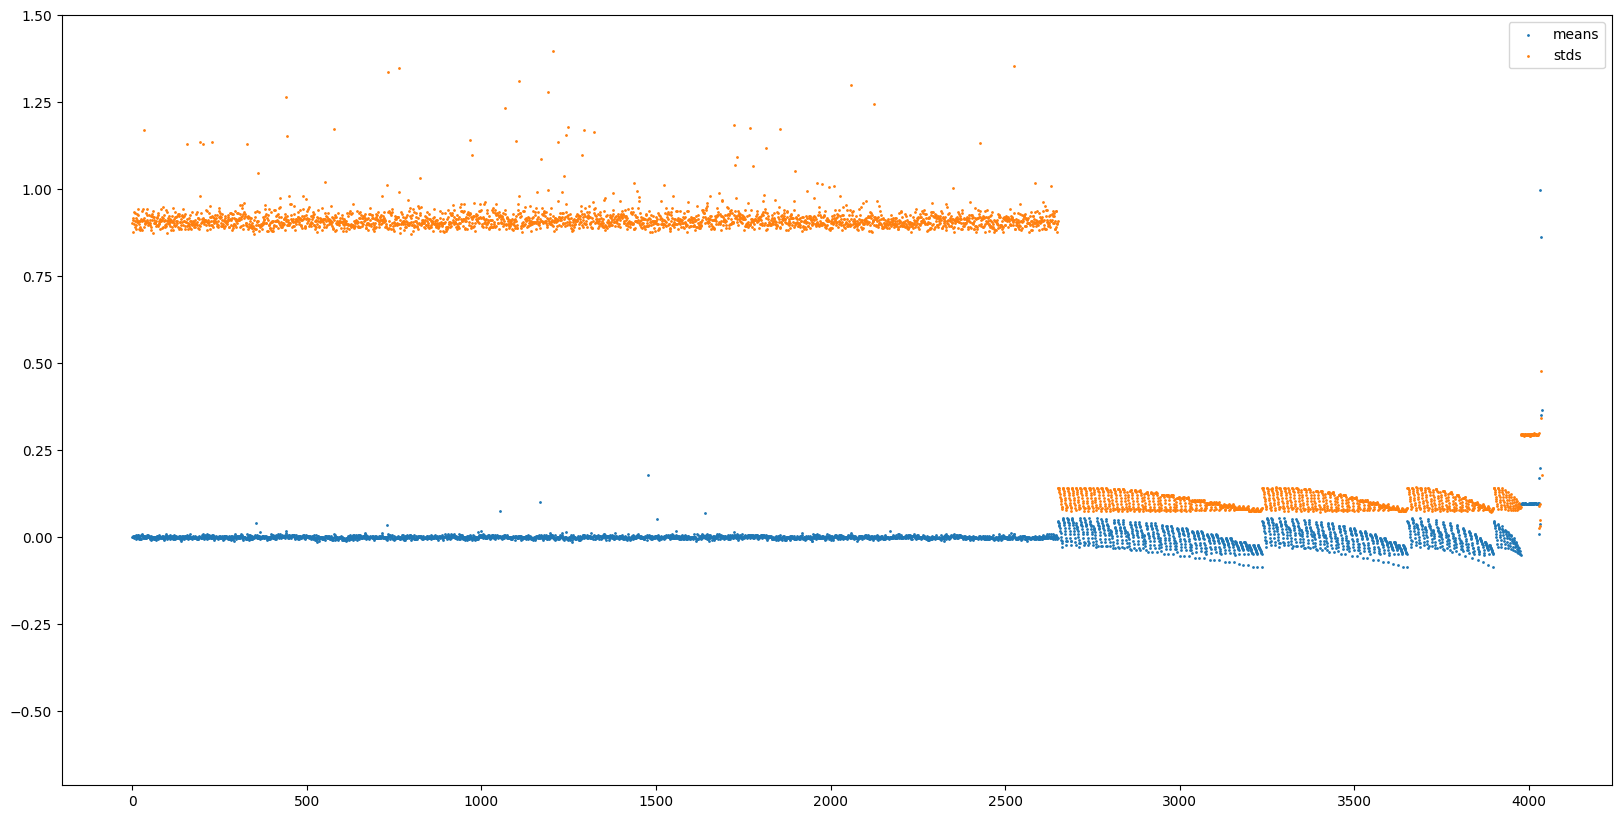

In [15]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means", s=1)
plt.scatter(range(df.std().size), df.std(), label="stds", s=1)
plt.legend()
plt.ylim(top=1.5)
plt.show()

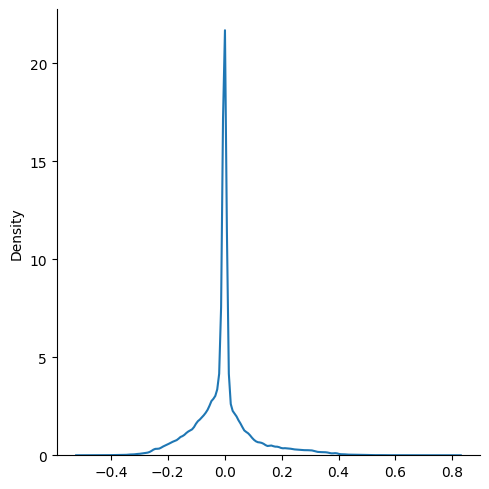

In [16]:
# Plot distribution of target values in a bell curve
from seaborn import displot

# Sample 1000 rows to speed up plotting
displot(df[value_columns].sample(1000).to_numpy().flatten(), kind="kde")
plt.show()

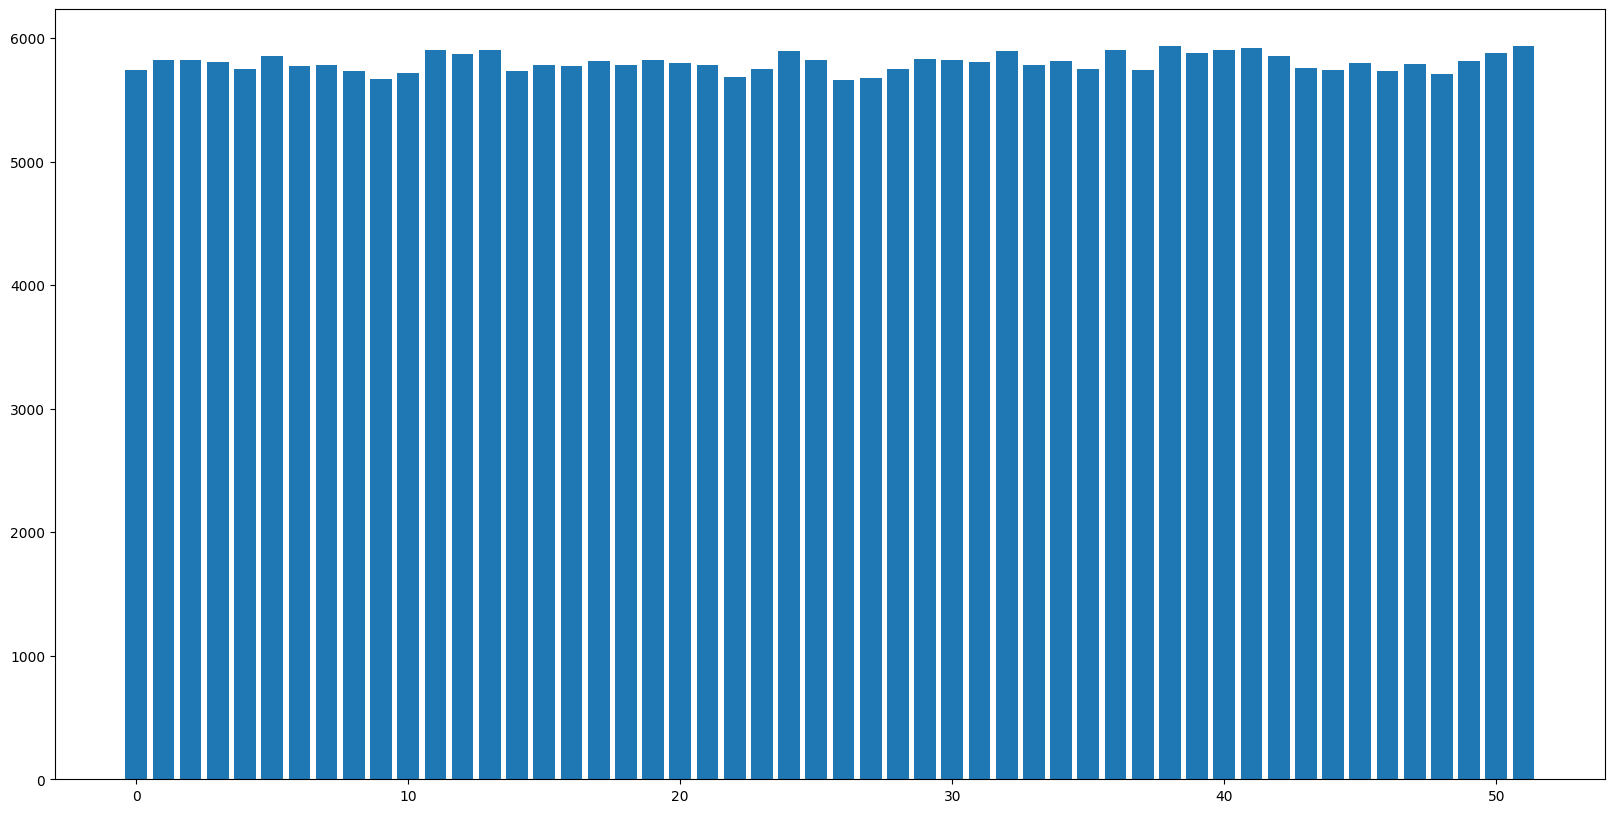

In [17]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_") and "*" not in col]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

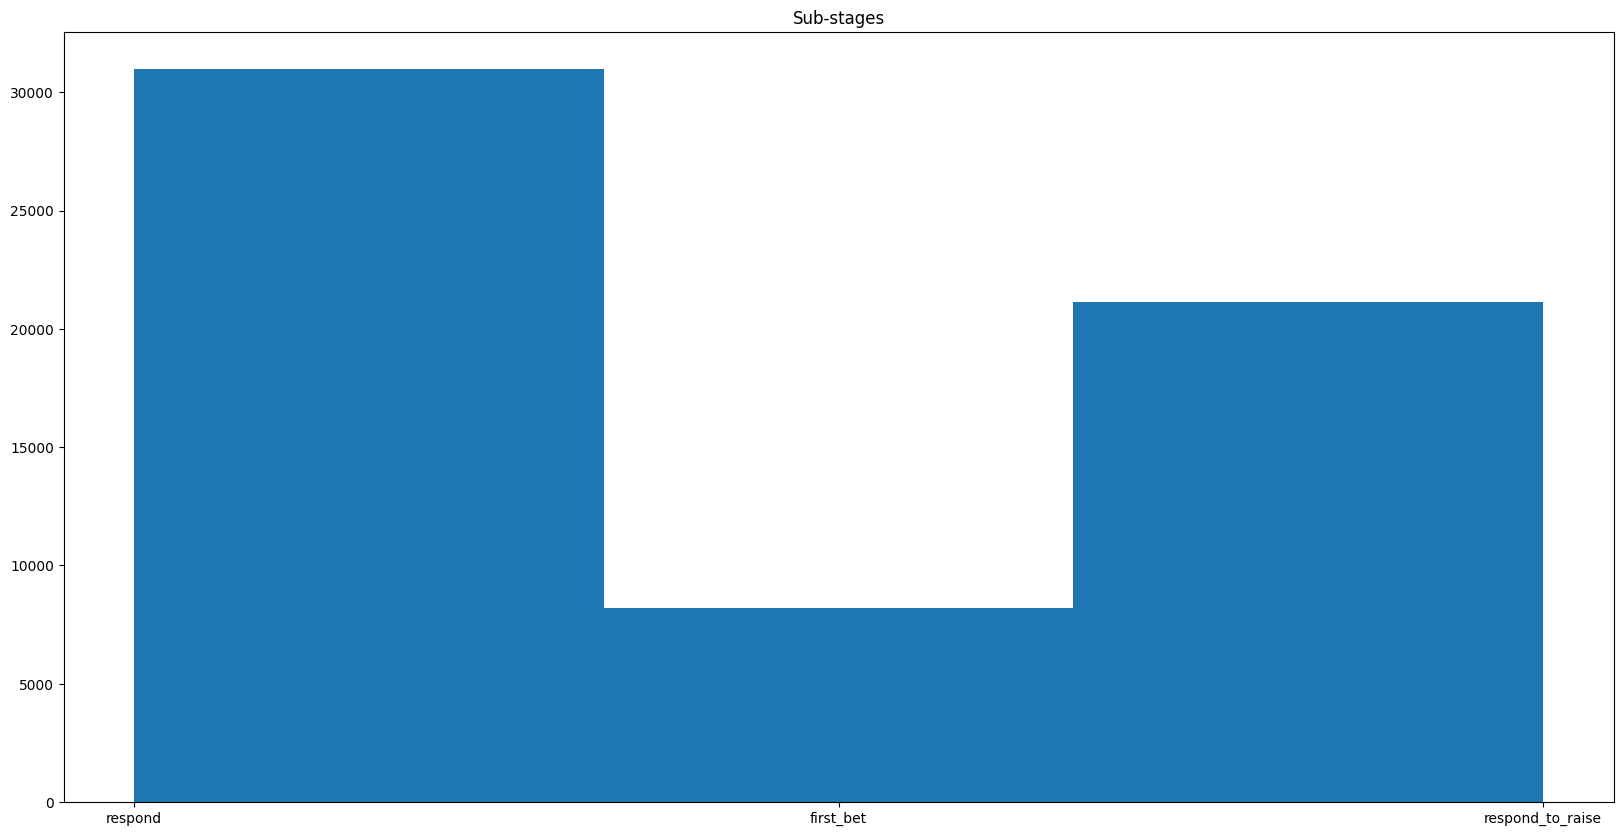

In [18]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [19]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(60340, 2712) (60340, 1326)


### Structure for Neural Network

In [20]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [21]:
def generate_model(l1_rate=1e-9, l2_rate=1e-8):
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define a small standard deviation for the initial weights
    init = RandomNormal(mean=0.0, stddev=0.002, seed=42)

    # Only use one hidden layer for now because we have so little data
    hidden_layer_1 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(input_layer)

    hidden_layer_2 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_2",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_1)

    hidden_layer_3 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_3",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_2)

    # Add a dropout layer to prevent overfitting
    # dropout_layer = Dropout(0.5)(hidden_layer_3)

    # Define output layer
    value_layer_P1 = Dense(
        Y.shape[1],
        activation="linear",
        name="value_layer_P1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_3)

    # Naturally, the target variable is centered around 0 with a SD of ~0.1, thus
    # to get an SD of 1, it is scaled by 10. To make this scaling implicit in the model,
    # rather than having to do it in the preprocessing, we add a scaling layer here.
    scaling_layer = Lambda(lambda x: x * 10)(value_layer_P1)

    # Create an Adam optimizer with a small learning rate
    small_lr_optimizer = Adam(learning_rate=0.000001)

    # Create model
    model = Model(inputs=input_layer, outputs=scaling_layer)
    model.compile(optimizer=small_lr_optimizer, loss="mean_squared_error")

    return model

### Split data

In [22]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Cross validation

In [23]:
# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []
validation_predictions = []
validation_actuals = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

folds = list(kf.split(X_train))
# folds = folds[:1] # Limit the number of folds to look at

# Loop over each fold
for i, (train_index, val_index) in enumerate(folds):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)
    validation_predictions.append(model.predict(X_val_fold))
    validation_actuals.append(Y_val_fold)

@@@ FOLD 1 @@@
Size of training set: 38617


2024-08-21 15:48:40.423333: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-08-21 15:48:40.427043: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-08-21 15:48:40.430027: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-08-21 15:48:40.436153: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-08-21 15:48:40.442219: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/1000


2024-08-21 15:48:45.287803: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1207/1207 [==============================] - ETA: 0s - loss: 0.0104

2024-08-21 16:29:09.641200: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1207/1207 [==============================] - 4393s 4s/step - loss: 0.0104 - val_loss: 0.0089
Epoch 2/1000
1197/1207 [============================>.] - ETA: 18s - loss: 0.0083

KeyboardInterrupt: 

In [ ]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history["val_loss"]
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
baseline_mse = np.mean((Y_test - np.mean(Y_train, axis=0)) ** 2)
print(f"Baseline MSE: {baseline_mse:.4f}")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Cross-Validation MSE: 0.0084 (+/- 0.0000)
Baseline MSE: 0.0108
Cross-Validation RMSE: 0.0915 (+/- 0.0000)
Baseline RMSE: 0.1040


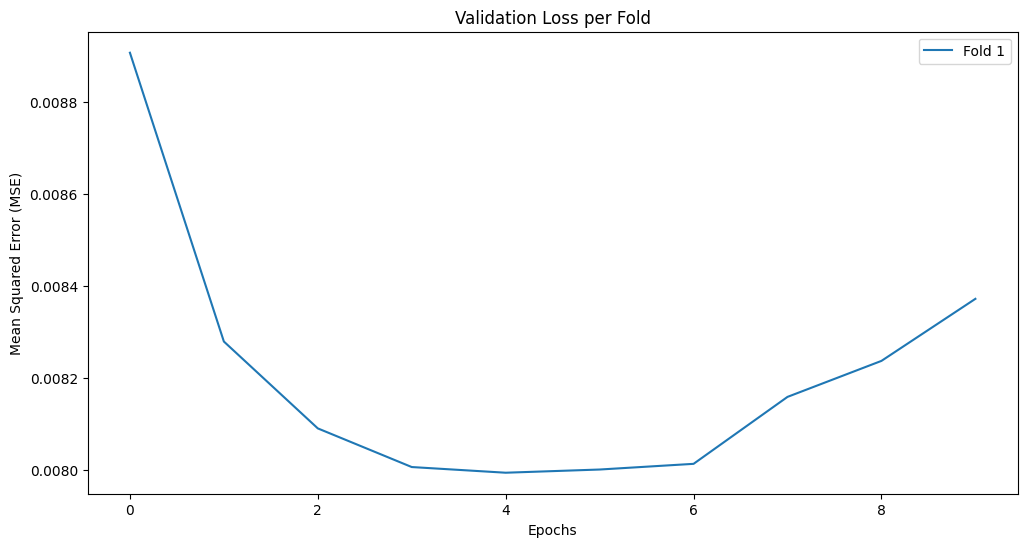

In [ ]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

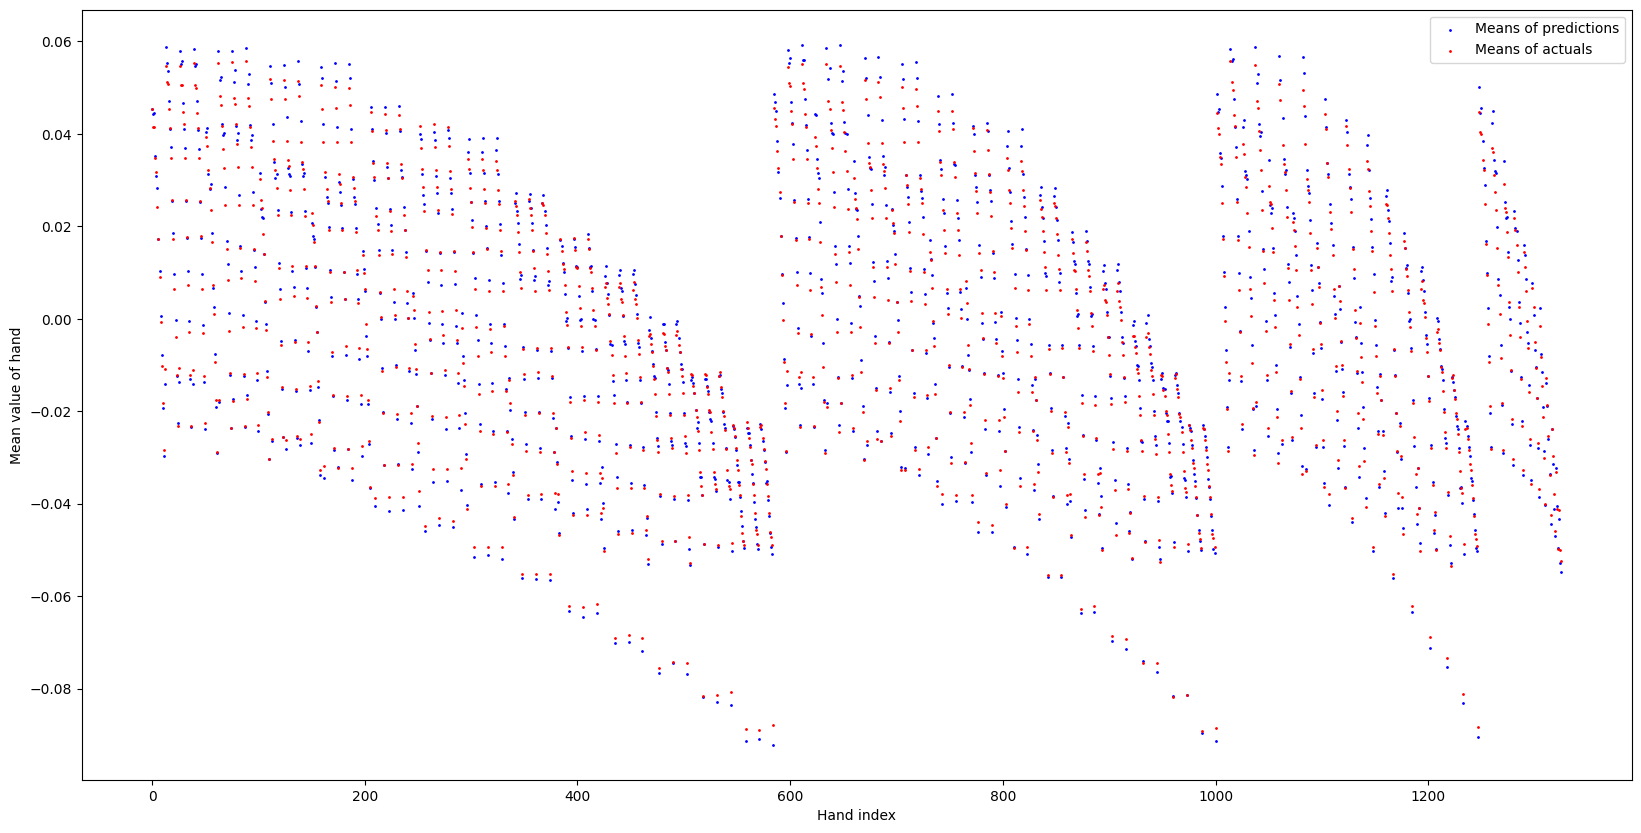

In [ ]:
# Plot the distribution of outputs from the model
Y_val_pred = np.concatenate(validation_predictions)
Y_val = np.concatenate(validation_actuals)
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.mean(axis=0).size),
    Y_val_pred.mean(axis=0),
    label="Means of predictions",
    s=1,
    c="blue",
)
plt.scatter(
    range(Y_val.mean(axis=0).size),
    Y_val.mean(axis=0),
    label="Means of actuals",
    s=1,
    c="red",
)        
plt.xlabel("Hand index")
plt.ylabel("Mean value of hand")
plt.legend()
plt.show()

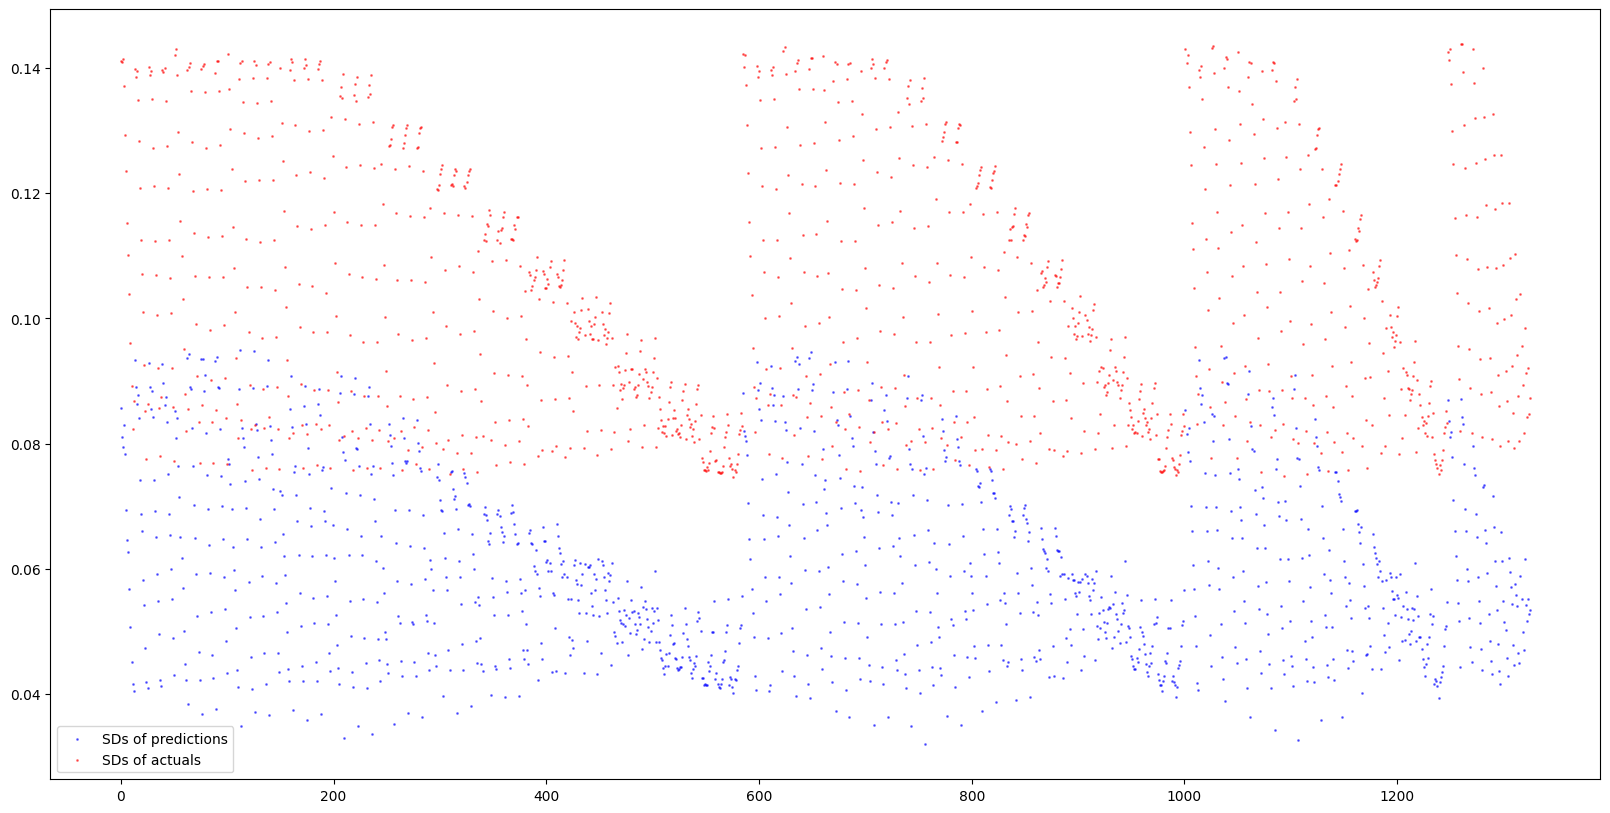

In [ ]:
# Plot the distribution of outputs from the model
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.std(axis=0).size),
    Y_val_pred.std(axis=0),
    label="SDs of predictions",
    s=1,
    c="blue",
    alpha=0.5,
)
plt.scatter(
    range(Y_val.std(axis=0).size),
    Y_val.std(axis=0),
    label="SDs of actuals",
    s=1,
    c="red",
    alpha=0.5,
)
plt.legend()
plt.show()

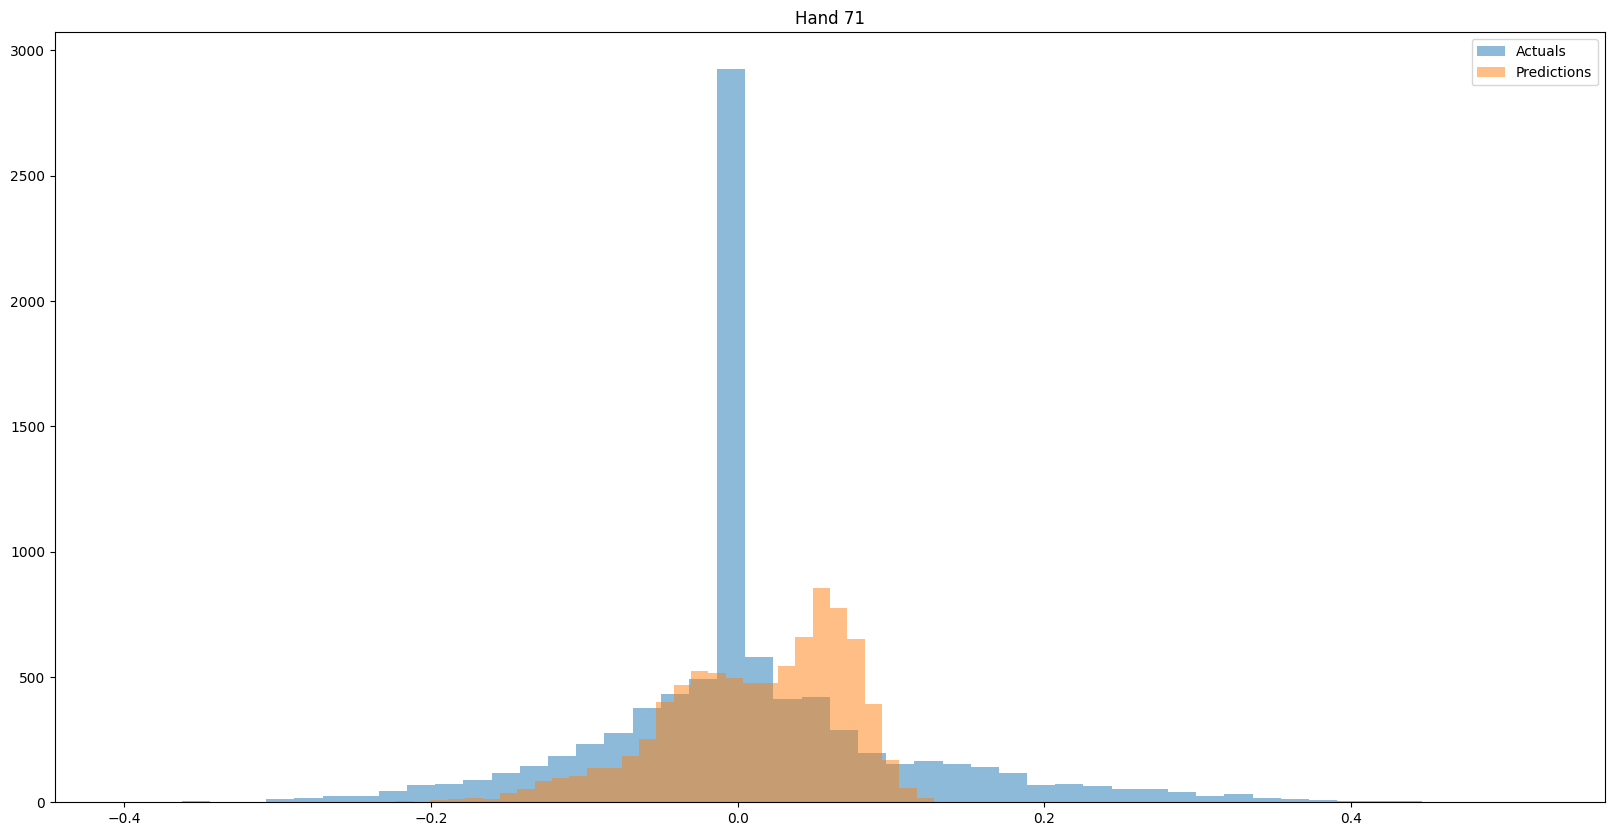

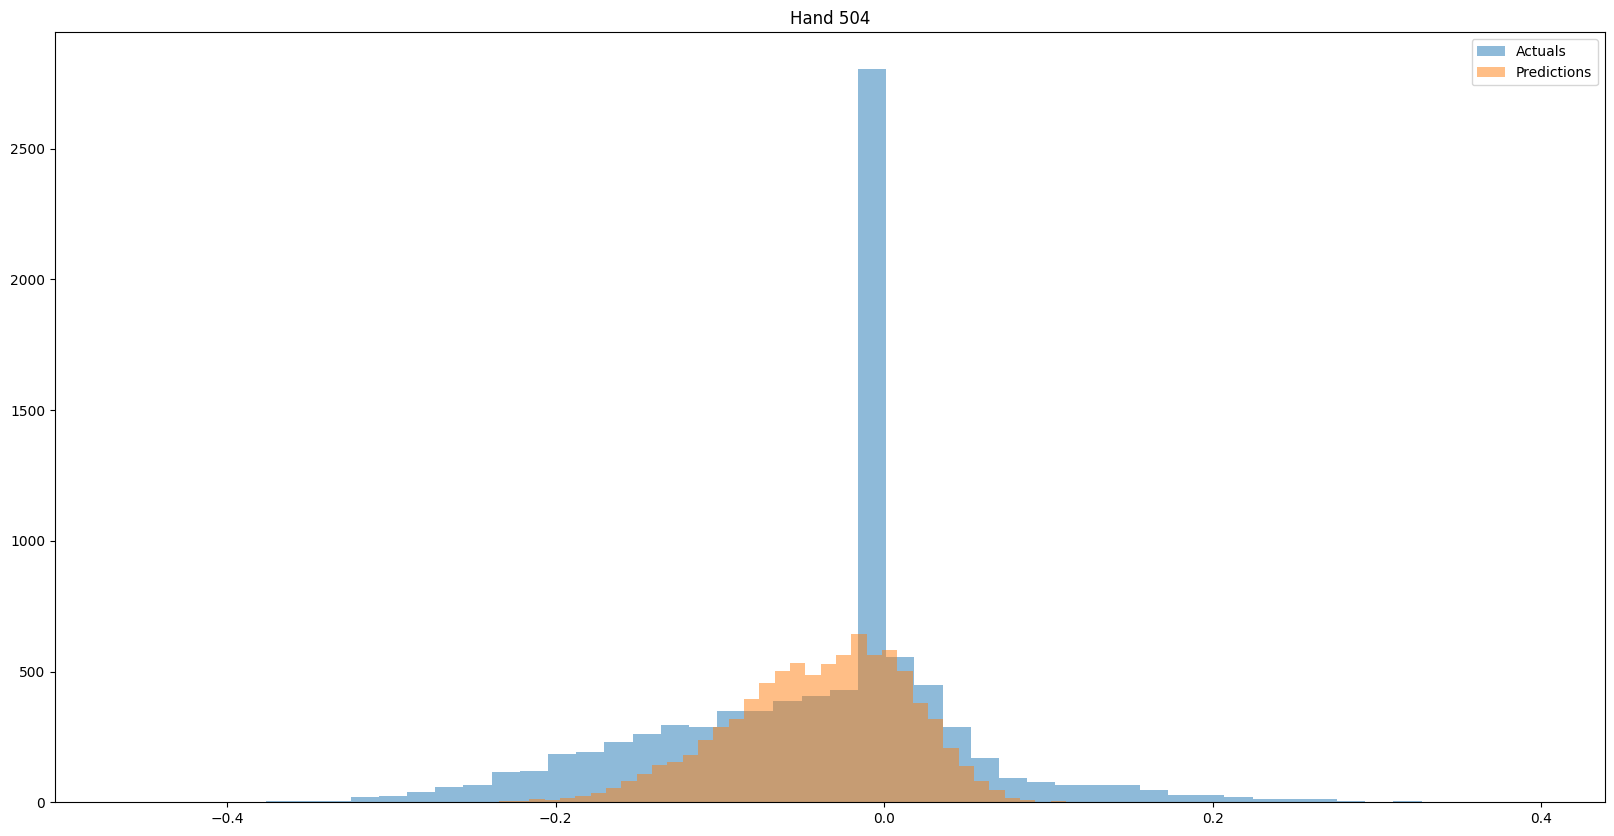

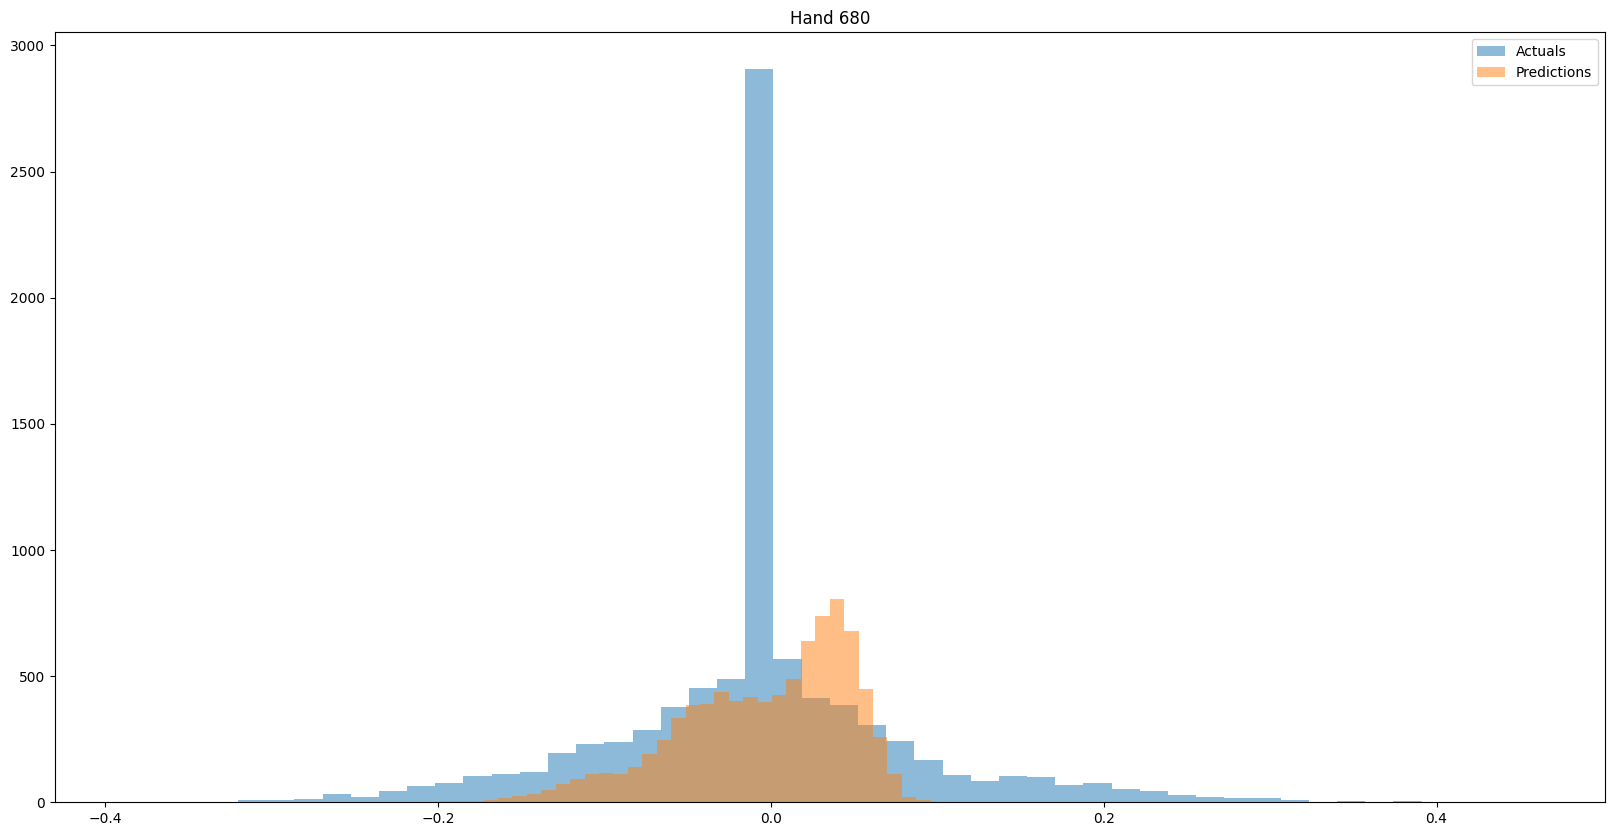

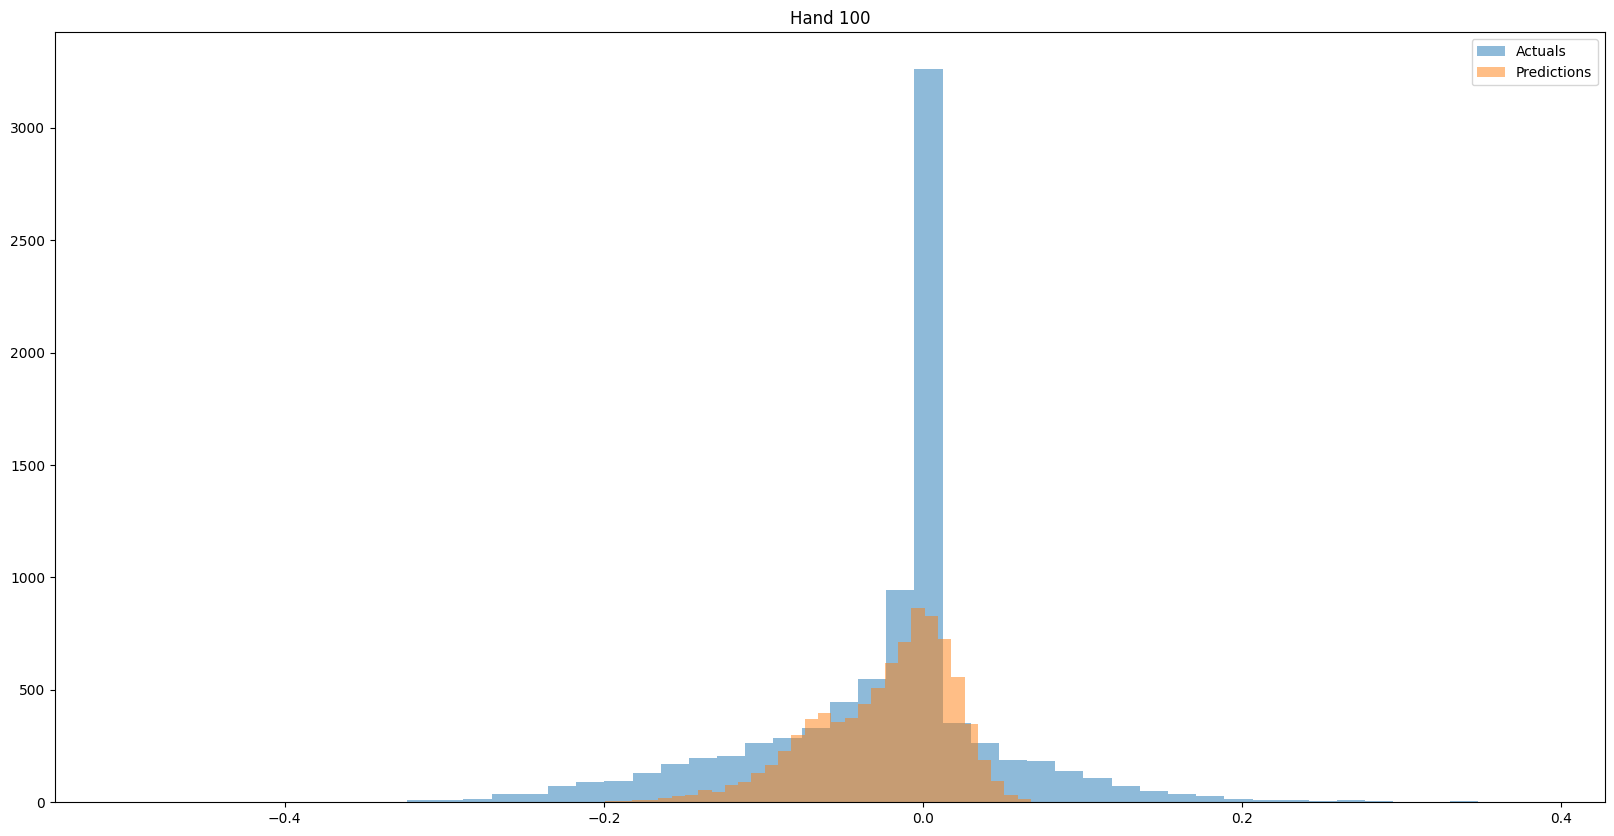

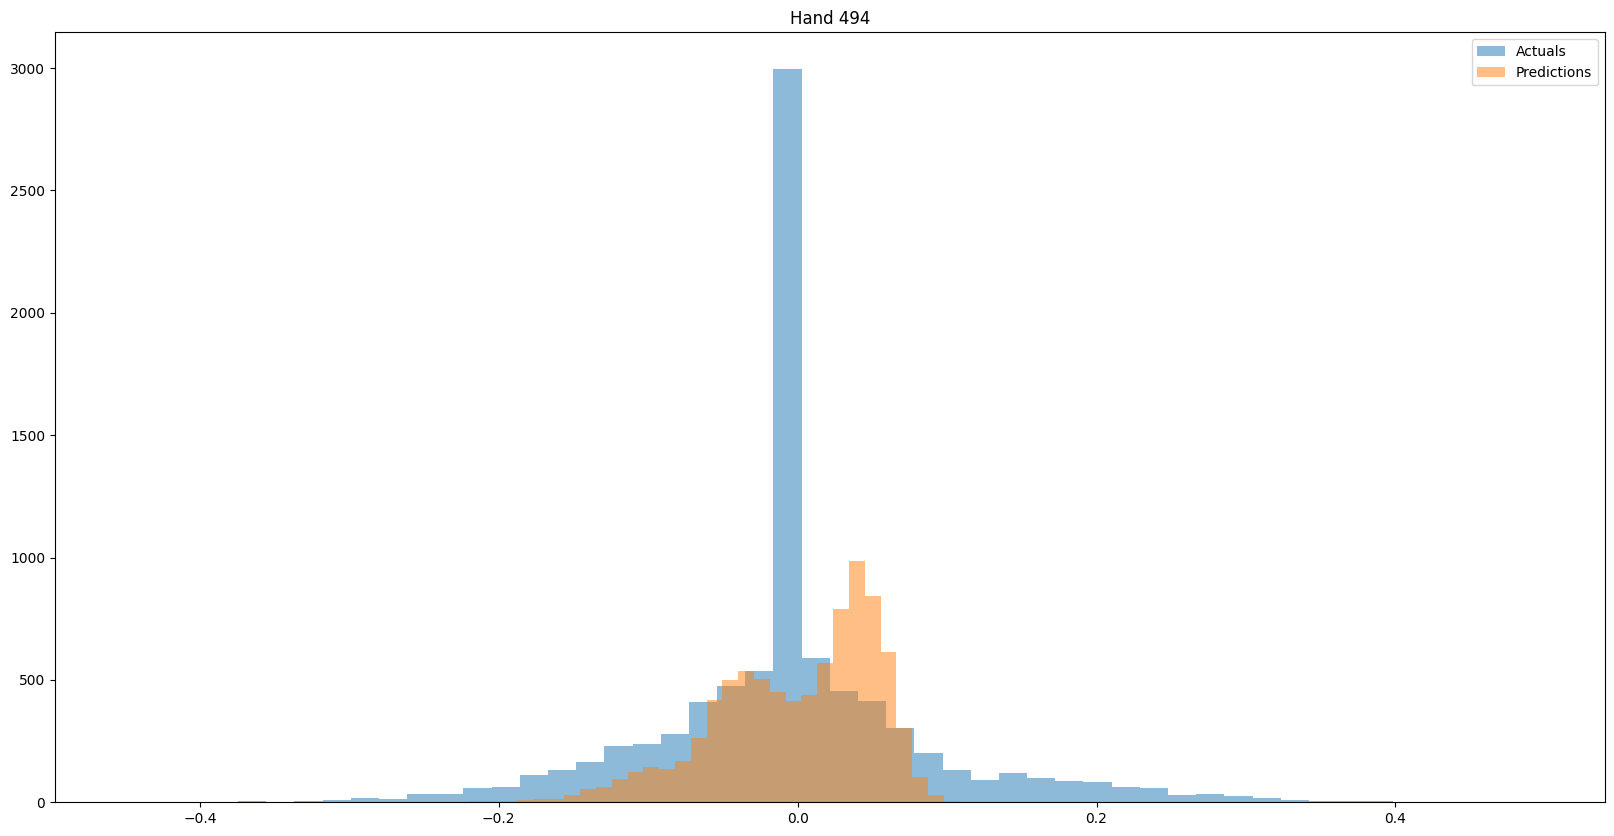

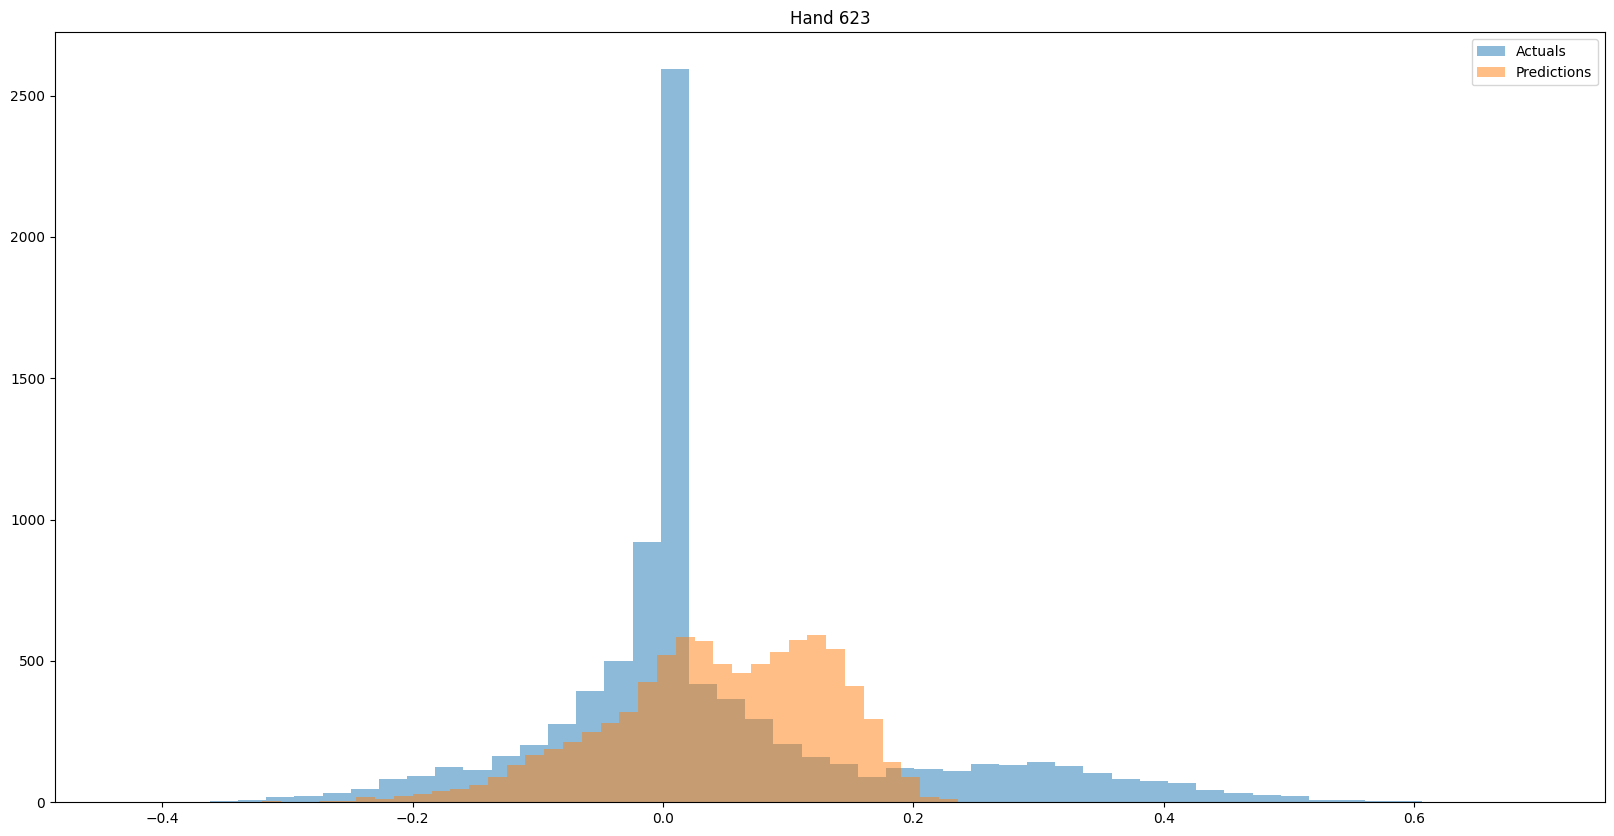

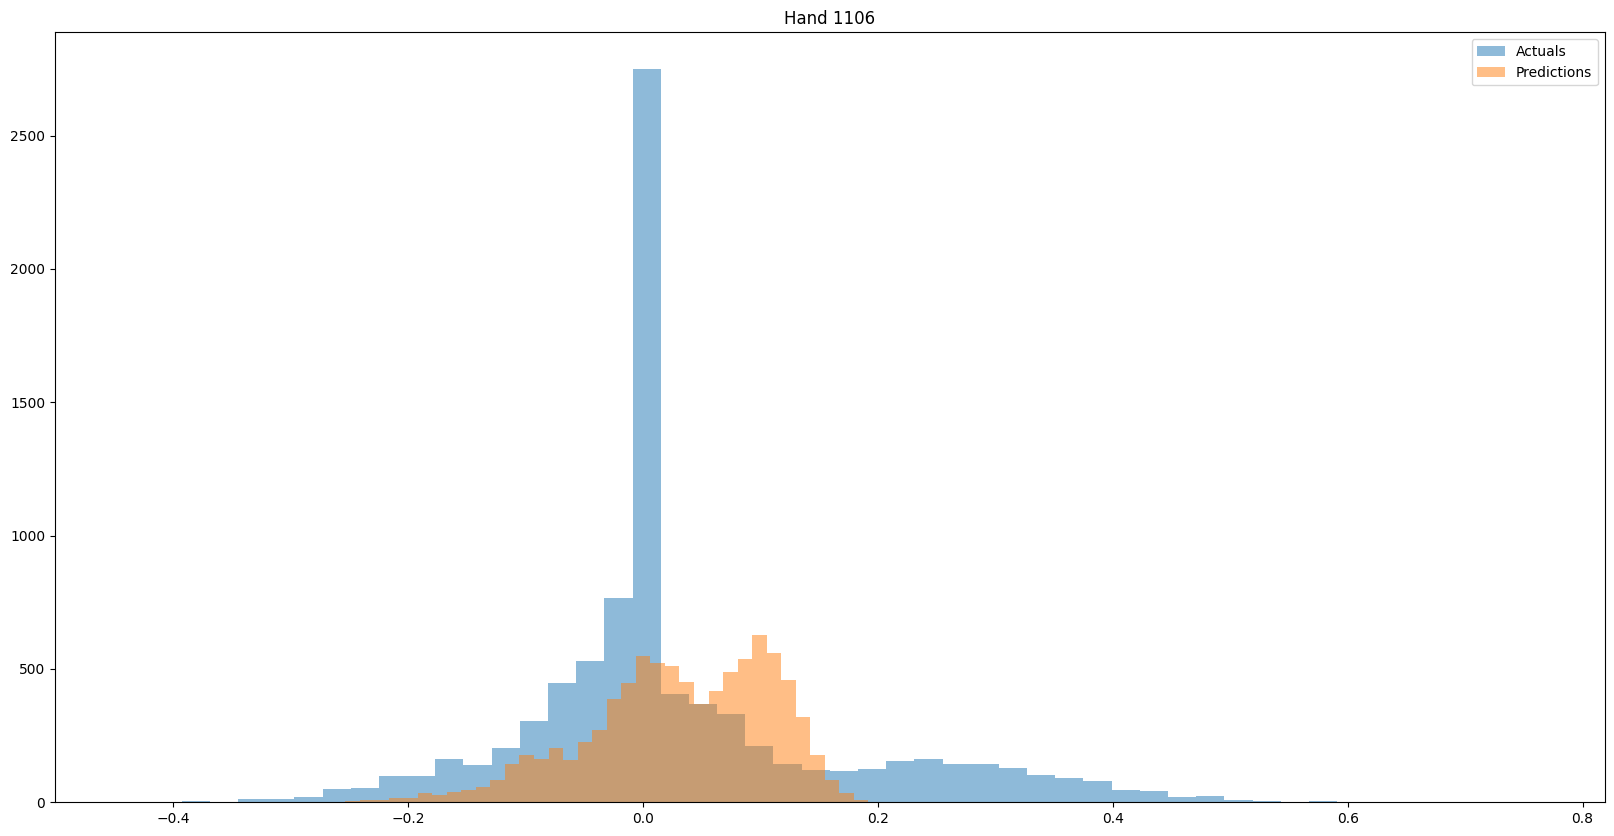

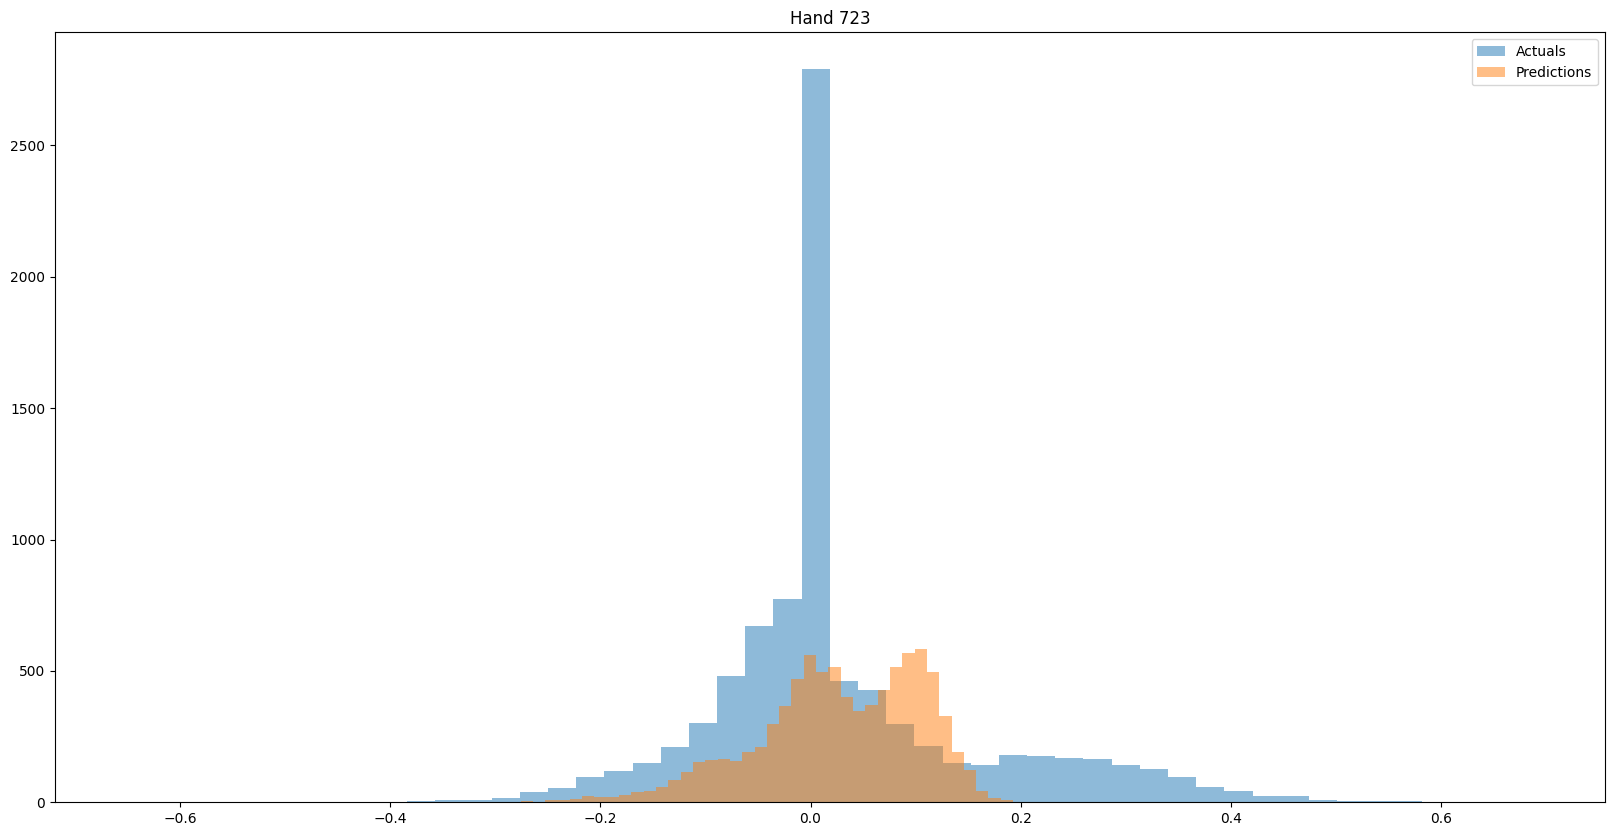

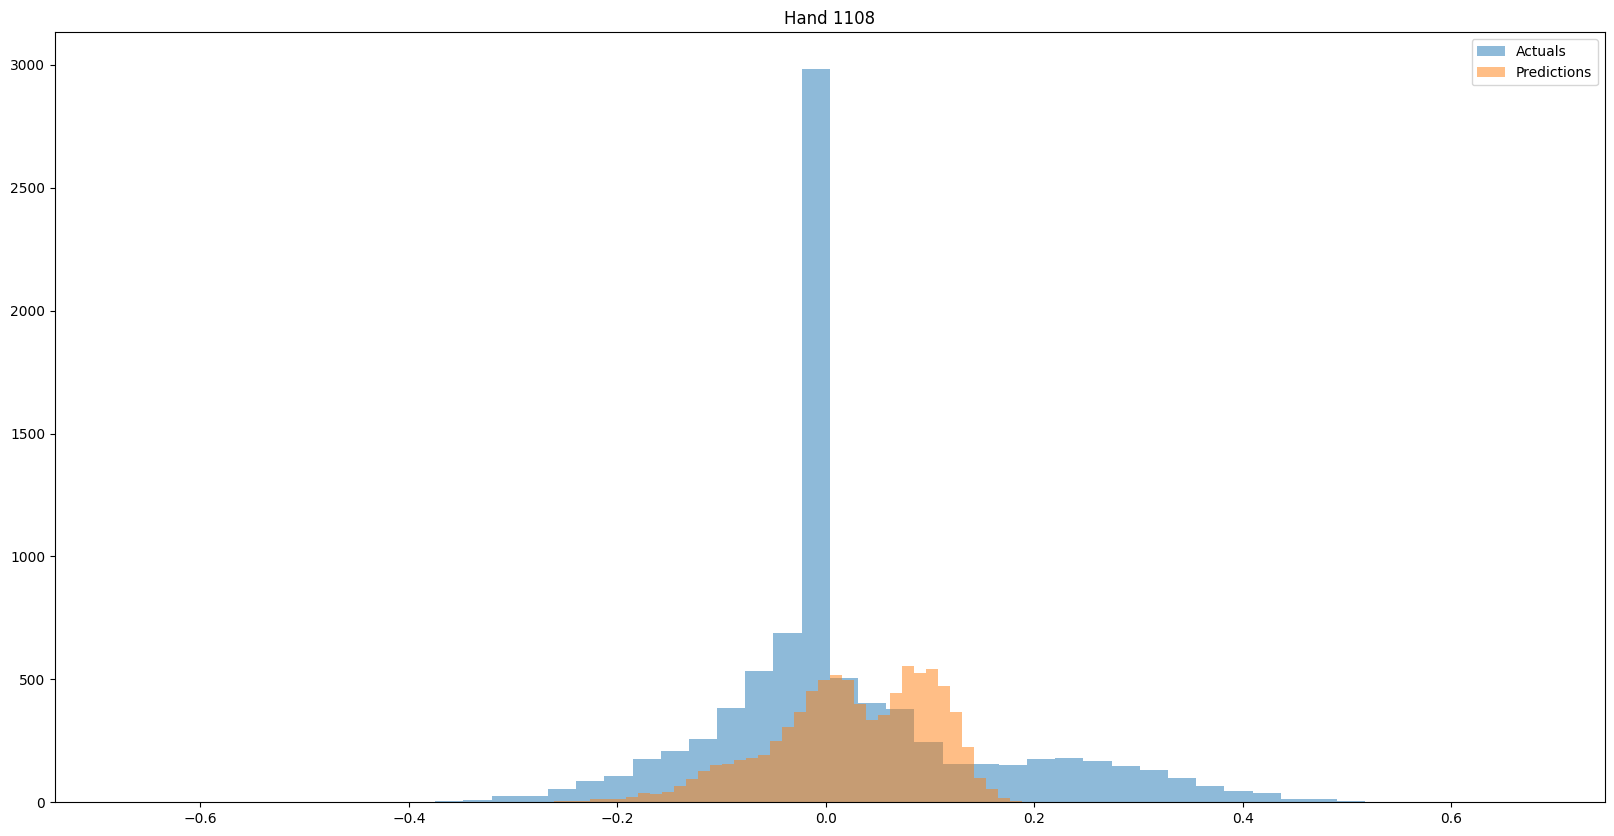

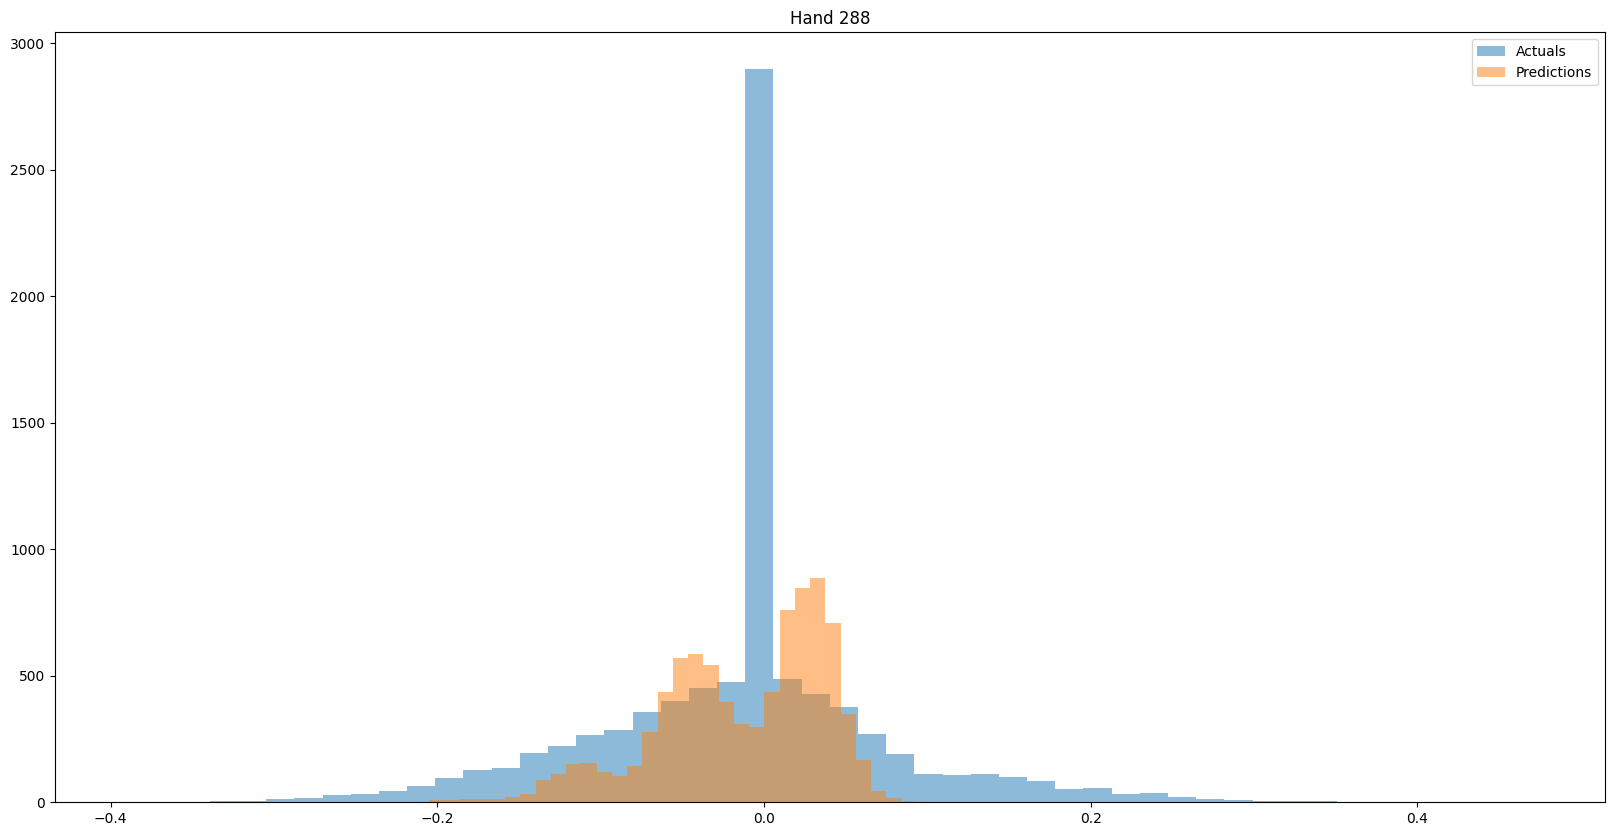

In [ ]:
# Look at 10 random hands and compare the predicted and actual values
sample_is = np.random.choice(Y_val.shape[1], 10)
for i in sample_is:
    # Plot histogram of actual values
    fig, ax = plt.subplots(figsize=(20, 10))
    plt.hist(Y_val[:, i], bins=50, alpha=0.5, label="Actuals")
    plt.hist(Y_val_pred[:, i], bins=50, alpha=0.5, label="Predictions")
    plt.legend()
    plt.title(f"Hand {i}")
    plt.show()

In [ ]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
final_epoch_number = int(average_optimal_epoch)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 4


In [ ]:
# Clear memory
fold_results = []
gc.collect()

95897

### Testing

In [ ]:
# Test the model
model = generate_model()
epochs = final_epoch_number
model.fit(X_train, Y_train, epochs=epochs)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/4


2024-08-19 22:35:07.445749: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1350/1350 [==============================] - 495s 366ms/step - loss: 0.0103
Epoch 2/4
1350/1350 [==============================] - 472s 349ms/step - loss: 0.0082
Epoch 3/4
1350/1350 [==============================] - 468s 347ms/step - loss: 0.0079
Epoch 4/4
  1/338 [..............................] - ETA: 1:14 - loss: 0.0082

2024-08-19 23:07:07.117515: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


338/338 [==============================] - 30s 88ms/step - loss: 0.0078
Test MSE: 0.0078
Test RMSE: 0.0885


In [ ]:
# As a baseline, calculate the RMSE of predicting only zeros
baseline_mse = np.mean(Y_test**2)
print(f"Baseline MSE: {baseline_mse:.4f}")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MSE: 0.0117
Baseline RMSE: 0.1081


In [ ]:
# As a better baseline, calculate the RMSE of predicting the mean of the target variable
mean_target = np.mean(Y_train, axis=0)
mean_baseline_mse = np.mean((Y_test - mean_target)**2)
print(f"Mean Baseline MSE: {mean_baseline_mse:.4f}")
mean_baseline_rmse = np.sqrt(mean_baseline_mse)
print(f"Mean Baseline RMSE: {mean_baseline_rmse:.4f}")

Mean Baseline MSE: 0.0108
Mean Baseline RMSE: 0.1040


In [ ]:
# Clear memory
model = None
gc.collect()

4551

### Training of final model

In [ ]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=epochs)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

Epoch 1/4


2024-08-19 23:07:48.911944: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1687/1687 [==============================] - 73460s 44s/step - loss: 0.0099
Epoch 2/4
1687/1687 [==============================] - 61521s 36s/step - loss: 0.0081
Epoch 3/4
1687/1687 [==============================] - 5402s 3s/step - loss: 0.0078
Epoch 4/4
1687/1687 [==============================] - 619s 367ms/step - loss: 0.0077


/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Load model
model = tf.keras.models.load_model(f"models/{latest_fname}")
gc.collect()

993

In [ ]:
# Test making a point prediction
X_test_point = X_test[0].reshape(1, -1)
Y_test_point = Y_test[0].reshape(1, -1)
print("X_test_point shape:", X_test_point.shape)
Y_pred_point = model.predict(X_test_point)
print("Test point prediction:")
print("Actual:", Y_test_point)
print("Predicted:", Y_pred_point)

X_test_point shape: (1, 2712)
1/1 [==============================] - 0s 226ms/step


2024-08-21 14:17:56.139371: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Test point prediction:
Actual: [[-0.00613485 -0.03621715 -0.00605079 ... -0.00958397 -0.03409733
  -0.03465496]]
Predicted: [[ 0.02693408 -0.08390058  0.03483344 ... -0.02384561 -0.07735658
  -0.08118345]]
